In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import squareform
from pathlib import Path
from matplotlib.lines import Line2D
from datetime import datetime

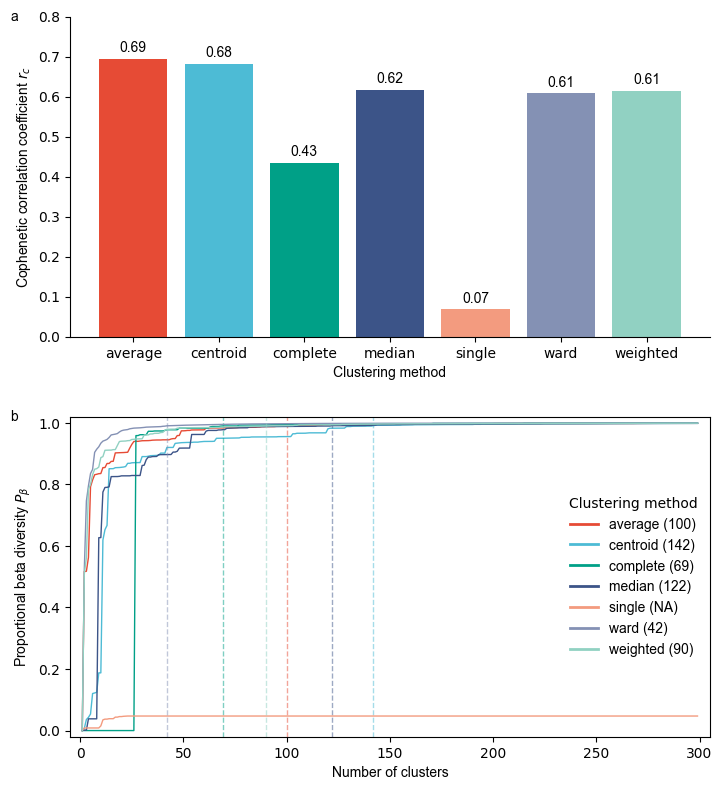

In [18]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_axes([0, 0.6, 0.8, 0.4])
methods = ['average', 'centroid', 'complete', 'median', 'single', 'ward', 'weighted']
colors = ['#E64B35FF', '#4DBBD5FF', '#00A087FF', '#3C5488FF', '#F39B7FFF', '#8491B4FF', '#91D1C2FF', '#dC0000FF', '#7E6148FF', '#B09C85FF']
df=pd.read_excel(f'output/scenario=all/cell=40km/threshold=5/cluster_method/all_40km_5_accuracy.xlsx')
bars = ax.bar(df['method'], df['cophenetic_correlation_coefficient'], color=colors[:len(methods)], width=0.8)
ax.set_xlabel('Clustering method', fontsize=10, fontfamily='Arial')
ax.set_ylabel('Cophenetic correlation coefficient $r_{c}$', fontsize=10, fontfamily='Arial')
ax.set_ylim(0, 0.8)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

for bar, v in zip(bars, df['cophenetic_correlation_coefficient']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontfamily='Arial')

ax = fig.add_axes([0, 0.1, 0.8, 0.4])
linkage_methods=('average', 'centroid', 'complete', 'median', 'single', 'ward', 'weighted')
colors = [
    '#E64B35FF', '#4DBBD5FF', '#00A087FF', '#3C5488FF',
    '#F39B7FFF', '#8491B4FF', '#91D1C2FF',
    '#DC0000FF', '#7E6148FF', '#B09C85FF'
]

# method → color 映射（按顺序）
method_colors = {method: colors[i % len(colors)] for i, method in enumerate(linkage_methods)}

threshold_clusters = {}
df=pd.read_excel(f'output/scenario=all/cell=40km/threshold=5/cluster_method/all_40km_5_performance.xlsx')
for method in linkage_methods:
    df_m = df[df['method'] == method]
    c = method_colors[method]

    # ---- Pbeta 曲线
    ax.plot(
        df_m['n_clusters'],
        df_m['Pbeta'],
        lw=1.0,
        color=c
    )

    # ---- 找到 Pbeta ≥ 0.99 的最小 K
    hit = df_m[df_m['Pbeta'] >= 0.99]
    if not hit.empty:
        k_min = hit['n_clusters'].iloc[0]
        threshold_clusters[method] = k_min

        # ---- 对应颜色的竖直线
        ax.axvline(
            x=k_min,
            linestyle='--',
            lw=1.0,
            color=c,
            alpha=0.5
        )

# ---- 绘制图例：显示方法名 + k_min
legend_elements = []
for method in linkage_methods:
    k_min = threshold_clusters.get(method, None)
    label = f'{method} ({k_min})' if k_min is not None else f'{method} (NA)'
    legend_elements.append(
        plt.Line2D([0], [0], color=method_colors[method], lw=2, label=label)
    )

ax.set_xlabel('Number of clusters', fontsize=10, fontfamily='Arial')
ax.set_ylabel(r'Proportional beta diversity $P_\beta$', fontsize=10, fontfamily='Arial')
ax.set_ylim(-0.02, 1.02)
ax.set_xlim(-5, 305)
ax.legend(handles=legend_elements, frameon=False, title='Clustering method', title_fontsize=10, fontsize=10, ncol=1,  prop={'family': 'Arial'})

import string
letters = list(string.ascii_lowercase)
fig.text(-0.07, 1.0, letters[0], ha='center', va='center', fontsize=10, fontfamily='Arial')
fig.text(-0.07, 0.5, letters[1], ha='center', va='center', fontsize=10, fontfamily='Arial')


date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(f'figure/Supplementary Fig 2_{date_str}.tif', dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import squareform
from pathlib import Path
from matplotlib.lines import Line2D
from datetime import datetime

def method_to_clustering(scenario, cell_size, threshold):
    methods = ['average', 'centroid', 'complete', 'median', 'single', 'ward', 'weighted']
    colors = ['#E64B35FF', '#4DBBD5FF', '#00A087FF', '#3C5488FF', '#F39B7FFF', '#8491B4FF', '#91D1C2FF', '#dC0000FF', '#7E6148FF', '#B09C85FF']
    # --------------------------
    # 1. Load beta diversity matrix once
    # --------------------------
    file_path = Path(f'output/scenario={scenario}/cell={cell_size//1000}km/threshold={threshold}/'
                     f'{scenario}_{cell_size//1000}km_{threshold}_beta_diversity_matrix.xlsx')
    dissimilarity_matrix = pd.read_excel(file_path, index_col=0).astype(float)

    # Convert to condensed distance for linkage
    condensed_dist = squareform(dissimilarity_matrix.values)

    ccc_values = []
    cophenetic_data = {}  # 保存不同方法的 cophenetic distances
    for method in methods:
        # Perform hierarchical clustering
        Z = linkage(condensed_dist, method=method)
        ccc, coph_dists = cophenet(Z, condensed_dist)
        ccc_values.append(ccc)
        cophenetic_data[method] = coph_dists

    # --------------------------
    # 2. Save results
    # --------------------------
    df = pd.DataFrame({'method': methods, 'cophenetic_correlation_coefficient': ccc_values})
    output_dir = file_path.parent / 'cluster_method'
    output_dir.mkdir(parents=True, exist_ok=True)
    df.to_excel(output_dir / f'{scenario}_{cell_size//1000}km_{threshold}_accuracy.xlsx', index=False)

    # --------------------------
    # 3. Plot bar chart of CCC
    # --------------------------
    fig, ax = plt.subplots(figsize=(7,5))
    bars = ax.bar(df['method'], df['cophenetic_correlation_coefficient'], color=colors[:len(methods)], width=0.8)
    ax.set_xlabel('Clustering method', fontsize=10)
    ax.set_ylabel('Cophenetic correlation coefficient $r_{c}$', fontsize=10)
    ax.set_ylim(0, 0.8)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
 
    for bar, v in zip(bars, ccc_values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=10)

    date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
    plt.tight_layout()
    output_dir = file_path.parent / 'cluster_method'
    output_dir.mkdir(parents=True, exist_ok=True)
    out_file_bar = output_dir / f'{scenario}_{cell_size//1000}km_{threshold}_accuracy_{date_str}.tif'
    plt.savefig(out_file_bar, bbox_inches='tight', pad_inches=0.05, dpi=300)
    plt.close()
    print(f"[INFO] Cophenetic correlation coefficients saved and figure saved: {out_file_bar}")

    # --------------------------
    # 4. Plot original beta dissimilarity vs cophenetic distance
    # --------------------------
    np.random.seed(42)
    n_sample = 10000
    total_n = len(condensed_dist)

    # 随机抽样索引（不放回）
    sample_idx = np.random.choice(
        total_n,
        size=min(n_sample, total_n),
        replace=False
    )

    fig2, axes = plt.subplots(3, 3, figsize=(9, 9))
    axes = axes.flatten()
    for i, method in enumerate(methods):
        ax = axes[i]

        sampled_beta = condensed_dist[sample_idx]
        sampled_coph = cophenetic_data[method][sample_idx]

        # x轴：cophenetic distance, y轴：original distance（beta diversity）
        ax.scatter(sampled_coph, sampled_beta, alpha=0.2, s=10, color=colors[i])

        max_val = max(
            np.max(cophenetic_data[method]),
            np.max(condensed_dist)
        )

        ax.plot(
            [0, max_val],
            [0, max_val],
            'k--',
            linewidth=1
        )
        
        ax.set_title(method, fontsize=10)
        ax.set_xlabel('Cophenetic distance', fontsize=10)
        ax.set_ylabel("Beta dissimilarity distance $\\beta_{sim}$", fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_xlim(left=0)
        # CCC 放在 legend
        legend_handle = Line2D(
            [], [], linestyle='none',
            label=f'CCC = {ccc_values[i]:.2f}'
        )

        ax.legend(
            handles=[legend_handle],
            loc='lower right',
            frameon=False,
            fontsize=9
        )

    # 删除多余的子图
    for j in range(len(methods), len(axes)):
        fig2.delaxes(axes[j])

    date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
    plt.tight_layout()
    output_dir = file_path.parent / 'cluster_method'
    output_dir.mkdir(parents=True, exist_ok=True)
    out_file = output_dir / f"{scenario}_{cell_size//1000}km_{threshold}_cophenetic_vs_beta_distance_{date_str}.tif"
    plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.close()
    print(f"[INFO] Cophenetic vs original beta distances figure saved: {out_file}")

# Example usage
method_to_clustering(scenario='all', cell_size=40000, threshold=5)
method_to_clustering(scenario='all', cell_size=40000, threshold=1)

[INFO] Cophenetic correlation coefficients saved and figure saved: output\scenario=all\cell=40km\threshold=5\cluster_method\all_40km_5_accuracy_20260110.tif
[INFO] Cophenetic vs original beta distances figure saved: output\scenario=all\cell=40km\threshold=5\cluster_method\all_40km_5_cophenetic_vs_beta_distance_20260110.tif


c:\Users\liuhc\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\cluster\hierarchy.py:1715: RuntimeWarning: invalid value encountered in scalar divide
  c = xp.sum(numerator) / xp.sqrt(xp.sum(denomA) * xp.sum(denomB))


[INFO] Cophenetic correlation coefficients saved and figure saved: output\scenario=all\cell=40km\threshold=1\cluster_method\all_40km_1_accuracy_20260110.tif
[INFO] Cophenetic vs original beta distances figure saved: output\scenario=all\cell=40km\threshold=1\cluster_method\all_40km_1_cophenetic_vs_beta_distance_20260110.tif


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from datetime import datetime

def compute_Pbeta_performance(
    scenario,
    cell_size,
    threshold,
    linkage_methods=('average', 'centroid', 'complete', 'median', 'single', 'ward', 'weighted'),
    cluster_range=range(1, 300)):

    # ======================================================
    # 1. 路径 & 读取 beta diversity 矩阵
    # ======================================================
    base = Path(
        f'output/scenario={scenario}/cell={cell_size // 1000}km/threshold={threshold}'
    )
    beta_file = base / f'{scenario}_{cell_size // 1000}km_{threshold}_beta_diversity_matrix.xlsx'

    beta_df = pd.read_excel(beta_file, index_col=0)
    beta = beta_df.values
    n = beta.shape[0]

    condensed_beta = squareform(beta, checks=False)

    # ======================================================
    # 2. 总 β 多样性（只算一次）
    # ======================================================
    triu_idx = np.triu_indices(n, k=1)
    total_sum = beta[triu_idx].sum()

    # ======================================================
    # 3. 计算 Pbeta（method × K）
    # ======================================================
    results = []

    for method in linkage_methods:
        print(f'[INFO] linkage method: {method}')

        Z = linkage(condensed_beta, method=method)

        for k in cluster_range:
            labels = fcluster(Z, k, criterion='maxclust')

            within_sum = 0.0
            for cl in np.unique(labels):
                idx = np.where(labels == cl)[0]
                if len(idx) <= 1:
                    continue

                sub = beta[np.ix_(idx, idx)]
                within_sum += sub[np.triu_indices(len(idx), k=1)].sum()

            pbeta = 1.0 - within_sum / total_sum if total_sum > 0 else 0.0

            results.append({
                'method': method,
                'n_clusters': k,
                'Pbeta': pbeta
            })

    results_df = pd.DataFrame(results)

    # ======================================================
    # 4. 保存结果
    # ======================================================
    output_dir = base / 'cluster_method'
    output_dir.mkdir(parents=True, exist_ok=True)

    out_file = output_dir / f"{scenario}_{cell_size//1000}km_{threshold}_performance.xlsx"
    results_df.to_excel(out_file, index=False)

    print(f'[INFO] Pbeta performance saved: {out_file}')


    # ======================================================
    # 5. 绘制 Pbeta 曲线 + 阈值竖线
    # ======================================================

    colors = [
        '#E64B35FF', '#4DBBD5FF', '#00A087FF', '#3C5488FF',
        '#F39B7FFF', '#8491B4FF', '#91D1C2FF',
        '#DC0000FF', '#7E6148FF', '#B09C85FF'
    ]

    # method → color 映射（按顺序）
    method_colors = {method: colors[i % len(colors)] for i, method in enumerate(linkage_methods)}

    fig, ax = plt.subplots(figsize=(8, 6))

    threshold_clusters = {}

    for method in linkage_methods:
        df_m = results_df[results_df['method'] == method]
        c = method_colors[method]

        # ---- Pbeta 曲线
        ax.plot(
            df_m['n_clusters'],
            df_m['Pbeta'],
            lw=1.0,
            color=c
        )

        # ---- 找到 Pbeta ≥ 0.99 的最小 K
        hit = df_m[df_m['Pbeta'] >= 0.99]
        if not hit.empty:
            k_min = hit['n_clusters'].iloc[0]
            threshold_clusters[method] = k_min

            # ---- 对应颜色的竖直线
            ax.axvline(
                x=k_min,
                linestyle='--',
                lw=1.0,
                color=c,
                alpha=0.5
            )

    # ---- 绘制图例：显示方法名 + k_min
    legend_elements = []
    for method in linkage_methods:
        k_min = threshold_clusters.get(method, None)
        label = f'{method} ({k_min})' if k_min is not None else f'{method} (NA)'
        legend_elements.append(
            plt.Line2D([0], [0], color=method_colors[method], lw=2, label=label)
        )

    ax.set_xlabel('Number of clusters', fontsize=10)
    ax.set_ylabel(r'Proportional beta diversity $P_\beta$', fontsize=10)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(-5, 305)
    ax.legend(handles=legend_elements, frameon=False, title='Clustering method', title_fontsize=10, fontsize=10, ncol=1)
    
    date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
    plt.tight_layout()
    fig_file = output_dir / f"{scenario}_{cell_size//1000}km_{threshold}_Pbeta_curve_{date_str}.tif"
    plt.savefig(fig_file, dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.close()
    print(f"[INFO] Cophenetic vs original beta distances figure saved: {out_file}")

# ================================
# Example usage
# ================================
compute_Pbeta_performance(scenario='all', cell_size=40000, threshold=5)
compute_Pbeta_performance(scenario='all', cell_size=40000, threshold=1)

[INFO] linkage method: average
[INFO] linkage method: centroid
[INFO] linkage method: complete
[INFO] linkage method: median
[INFO] linkage method: single
[INFO] linkage method: ward
[INFO] linkage method: weighted
[INFO] Pbeta performance saved: output\scenario=all\cell=40km\threshold=5\cluster_method\all_40km_5_performance.xlsx
[INFO] Cophenetic vs original beta distances figure saved: output\scenario=all\cell=40km\threshold=5\cluster_method\all_40km_5_performance.xlsx
[INFO] linkage method: average
[INFO] linkage method: centroid
[INFO] linkage method: complete
[INFO] linkage method: median
[INFO] linkage method: single
[INFO] linkage method: ward
[INFO] linkage method: weighted
[INFO] Pbeta performance saved: output\scenario=all\cell=40km\threshold=1\cluster_method\all_40km_1_performance.xlsx
[INFO] Cophenetic vs original beta distances figure saved: output\scenario=all\cell=40km\threshold=1\cluster_method\all_40km_1_performance.xlsx
